In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_volume_cube(
        volume,
        crop=(None, None, None),        # (nx, ny, nz) upper bounds, None -> full
        faces=('x0', 'x1', 'y0', 'y1', 'z0', 'z1'),
        internal_slices=None,           # e.g. {'z': [0, 10, 20], 'x': [5]}
        elev=30, azim=45,
        cmap='magma',
        vmin=None, vmax=None,
        bg_color='white',
        figsize=(5, 5)):
    """
    Plot a 3D cube where faces (and optional internal slices) show a 3D volume.

    Parameters
    ----------
    volume : ndarray, shape (Nx, Ny, Nz)
    crop : (cx, cy, cz)
        Upper bounds for slicing along x,y,z.
        - None means use full axis.
        - Example: (32, 64, 64) -> volume[:32, :64, :64]
    faces : iterable of {'x0','x1','y0','y1','z0','z1'}
        Which boundary faces to draw.
    internal_slices : dict or None
        Internal slice indices for each axis.
        Example: {'z': [0, 10, 20]} -> draw slices at those z indices.
    elev, azim : floats
        Camera angles.
    """
    vol = np.asarray(volume)

    # --- cropping ---
    sx = slice(0, crop[0]) if crop[0] is not None else slice(None)
    sy = slice(0, crop[1]) if crop[1] is not None else slice(None)
    sz = slice(0, crop[2]) if crop[2] is not None else slice(None)
    vol = vol[sx, sy, sz]

    nx, ny, nz = vol.shape

    if vmin is None:
        vmin = vol.min()
    if vmax is None:
        vmax = vol.max()

    cmap_obj = plt.get_cmap(cmap)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor(bg_color)
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor(bg_color)
    ax.set_box_aspect((1, 1, 1))

    xs = np.linspace(0, 1, nx)
    ys = np.linspace(0, 1, ny)
    zs = np.linspace(0, 1, nz)

    def surface_from_data(data, X, Y, Z, alpha=1.0):
        colors = cmap_obj(norm(data))
        colors[..., -1] = alpha
        ax.plot_surface(
            X, Y, Z,
            facecolors=colors,
            rstride=1, cstride=1,
            shade=False,
            antialiased=False,
            edgecolor='none'
        )

    # --- boundary faces ---
    for f in faces:
        if f == 'z0':  # front
            X, Y = np.meshgrid(xs, ys, indexing='ij')
            Z = np.zeros_like(X)
            surface_from_data(vol[:, :, 0], X, Y, Z)
        elif f == 'z1':  # back
            X, Y = np.meshgrid(xs, ys, indexing='ij')
            Z = np.ones_like(X)
            surface_from_data(vol[:, :, -1], X, Y, Z)
        elif f == 'y0':  # left
            X, Z = np.meshgrid(xs, zs, indexing='ij')
            Y = np.zeros_like(X)
            surface_from_data(vol[:, 0, :], X, Y, Z)
        elif f == 'y1':  # right
            X, Z = np.meshgrid(xs, zs, indexing='ij')
            Y = np.ones_like(X)
            surface_from_data(vol[:, -1, :], X, Y, Z)
        elif f == 'x0':  # bottom
            Y, Z = np.meshgrid(ys, zs, indexing='ij')
            X = np.zeros_like(Y)
            surface_from_data(vol[0, :, :], X, Y, Z)
        elif f == 'x1':  # top
            Y, Z = np.meshgrid(ys, zs, indexing='ij')
            X = np.ones_like(Y)
            surface_from_data(vol[-1, :, :], X, Y, Z)

    # --- internal slices (any axis) ---
    if internal_slices is not None:
        for axis, indices in internal_slices.items():
            for i in indices:
                if axis == 'x':
                    if not (0 <= i < nx): continue
                    y = ys
                    z = zs
                    Y, Z = np.meshgrid(y, z, indexing='ij')
                    X = np.full_like(Y, xs[i])
                    surface_from_data(vol[i, :, :], X, Y, Z, alpha=0.9)
                elif axis == 'y':
                    if not (0 <= i < ny): continue
                    x = xs
                    z = zs
                    X, Z = np.meshgrid(x, z, indexing='ij')
                    Y = np.full_like(X, ys[i])
                    surface_from_data(vol[:, i, :], X, Y, Z, alpha=0.9)
                elif axis == 'z':
                    if not (0 <= i < nz): continue
                    x = xs
                    y = ys
                    X, Y = np.meshgrid(x, y, indexing='ij')
                    Z = np.full_like(X, zs[i])
                    surface_from_data(vol[:, :, i], X, Y, Z, alpha=0.9)

    # axes / camera
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.view_init(elev=elev, azim=azim)

    ax.set_axis_off()
    ax.grid(False)

    return fig, ax


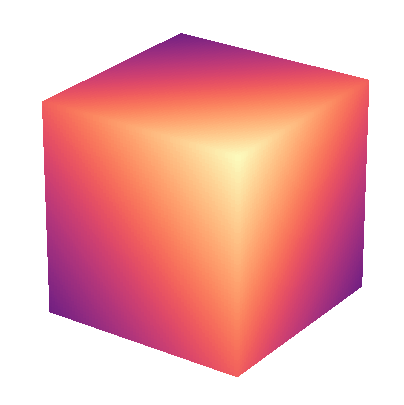

In [2]:
n = 64
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
z = np.linspace(0, 1, n)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
volume = X + Y + Z

fig, ax = plot_volume_cube(volume, elev=25, azim=35)
plt.show()


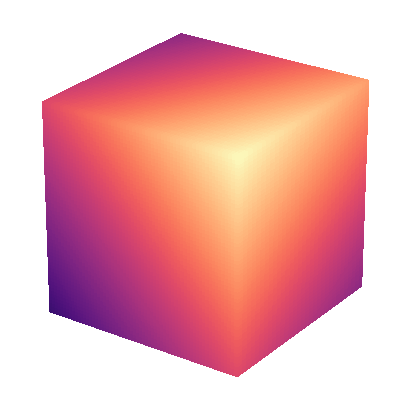

In [3]:
fig, ax = plot_volume_cube(volume,
                           crop=(32, 64, 64),
                           elev=25, azim=35)
plt.show()


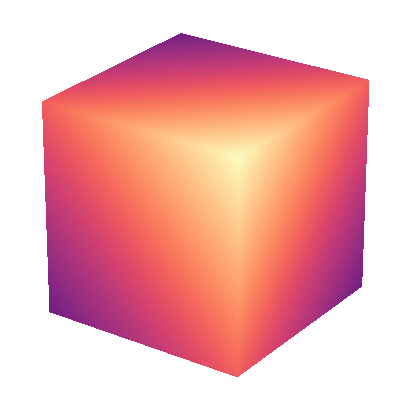

In [4]:
fig, ax = plot_volume_cube(volume,
                           internal_slices={'z': [0, 1, 10]},
                           elev=25, azim=35)
plt.show()
